# Convolutional Layers

In this lab, you will implement convolutional layers in the MLP framework and carry out some basic experiments to validate your implementation. 

We provide a convolutional layer skeleton as a class named `ConvolutionalLayer`. This class should implement the methods `fprop`, `bprop`, and `grads_wrt_params`. There are two recommended approaches you can use for the implementation (you can implement both or choose one):

* Using the methods `scipy.signal.convolve2d` (and/or `scipy.signal.correlate2d`)
* Using a **"serialisation" approach** with the `im2col` method

Both approaches are discussed below.

Associated test functions for the `fprop`, `bprop`, and `grads_wrt_params` methods of the `ConvolutionalLayer` class are included.

**Important assumptions for the test functions:**
- In your implementation of `fprop` for the convolutional layer, outputs are calculated only for **'valid' overlaps** of the kernel filters with the input (i.e., without any padding).
- If convolutions with non-unit strides are implemented, the default behaviour should use **unit strides**, with test cases only correct for unit strides in both directions.

## Implementation Approaches

When you implement a convolutional layer, both the `fprop` and `bprop` methods can be based on a convolution operation, as explained in the lectures. If we consider the `fprop`, the method operates on two 4-dimensional tensors:

* **The input** (previous layer activations) to the convolution, with dimensions `(batch_size, num_input_channels, input_dim_1, input_dim_2)`
* **The kernels** (weight matrices) for the convolutions, with dimensions `(num_output_channels, num_input_channels, kernel_dim_1, kernel_dim_2)`

The key to implementing a convolutional layer is how the convolutions are computed. We recommend considering one of the following approaches:

### Approach 1: Explicit Convolutions
Explicitly compute convolutions using the SciPy convolution function `scipy.signal.convolve2d` (or `scipy.signal.correlate2d`). Note that these functions convolve a 2D image with a 2D kernel, so your code will need to use them in the context of 4D tensors where we have multiple feature maps and a batch of training examples.

### Approach 2: Serialisation (im2col)
Use **"serialisation"** in which the convolution operation is turned into a single matrix multiplication. The advantage is that implementing the convolutional `fprop` or `bprop` as a single large matrix multiplication is much more computationally efficient than many small matrix multiplications in a naive implementation. The disadvantage is that the resulting matrix has repeated elements and can be large (dependent on the number of feature maps, batch size, and image size). 

This serialisation approach uses a function called `im2col` (and its reverse `col2im`). The `im2col` function is standard in MATLAB and various computer vision packages, but it is not part of NumPy or SciPy. You may use the external Python implementations `im2col_indices` and `col2im_indices` at:
https://github.com/huyouare/CS231n/blob/master/assignment2/cs231n/im2col.py

In [1]:
import mlp.layers as layers
import mlp.initialisers as init

from scipy.ndimage import convolve
from scipy.signal import convolve2d, correlate2d
import numpy as np

class ConvolutionalLayer(layers.LayerWithParameters):
    """Layer implementing a 2D convolution-based transformation of its inputs.

    The layer is parameterised by a set of 2D convolutional kernels, a four-
    dimensional array of shape
        (num_output_channels, num_input_channels, kernel_dim_1, kernel_dim_2)
    and a bias vector, a one-dimensional array of shape
        (num_output_channels,)
    i.e., one shared bias per output channel.

    Assuming no padding is applied to the inputs so that outputs are only
    calculated for positions where the kernel filters fully overlap with the
    inputs, and that unit strides are used, the outputs will have spatial extent:
        output_dim_1 = input_dim_1 - kernel_dim_1 + 1
        output_dim_2 = input_dim_2 - kernel_dim_2 + 1
    """

    def __init__(self, num_input_channels, num_output_channels,
                 input_dim_1, input_dim_2,
                 kernel_dim_1, kernel_dim_2,
                 kernels_init=init.UniformInit(-0.01, 0.01),
                 biases_init=init.ConstantInit(0.),
                 kernels_penalty=None, biases_penalty=None):
        """Initialises a parameterised convolutional layer.

        Args:
            num_input_channels (int): Number of channels in inputs to
                layer (this may be the number of colour channels in the input
                images if used as the first layer in a model, or the
                number of output channels, a.k.a. feature maps, from a
                previous convolutional layer).
            num_output_channels (int): Number of channels in outputs
                from the layer, a.k.a. number of feature maps.
            input_dim_1 (int): Size of first input dimension of each 2D
                channel of inputs.
            input_dim_2 (int): Size of second input dimension of each 2D
                channel of inputs.
            kernel_dim_1 (int): Size of first dimension of each 2D channel of
                kernels.
            kernel_dim_2 (int): Size of second dimension of each 2D channel of
                kernels.
            kernels_init: Initialiser for the kernel parameters.
            biases_init: Initialiser for the bias parameters.
            kernels_penalty: Kernel-dependent penalty term (regulariser) or
                None if no regularisation is to be applied to the kernels.
            biases_penalty: Biases-dependent penalty term (regulariser) or
                None if no regularisation is to be applied to the biases.
        """
        self.num_input_channels = num_input_channels
        self.num_output_channels = num_output_channels
        self.input_dim_1 = input_dim_1
        self.input_dim_2 = input_dim_2
        self.kernel_dim_1 = kernel_dim_1
        self.kernel_dim_2 = kernel_dim_2
        self.kernels_init = kernels_init
        self.biases_init = biases_init
        self.kernels_shape = (
            num_output_channels, num_input_channels, kernel_dim_1, kernel_dim_2
        )
        self.inputs_shape = (
            None, num_input_channels, input_dim_1, input_dim_2
        )
        self.kernels = self.kernels_init(self.kernels_shape)
        self.biases = self.biases_init(num_output_channels)
        self.kernels_penalty = kernels_penalty
        self.biases_penalty = biases_penalty

    def fprop(self, inputs):
        """Forward propagates activations through the layer transformation.

        For inputs `x`, outputs `y`, kernels `K` and biases `b` the layer
        corresponds to `y = conv2d(x, K) + b`.

        Args:
            inputs: Array of layer inputs of shape 
                (batch_size, num_input_channels, input_dim_1, input_dim_2).

        Returns:
            outputs: Array of layer outputs of shape 
                (batch_size, num_output_channels, output_dim_1, output_dim_2).
        """
        output_dim_1 = self.input_dim_1 - self.kernel_dim_1 + 1
        output_dim_2 = self.input_dim_2 - self.kernel_dim_2 + 1
        batch_size = inputs.shape[0]
        outputs = np.zeros((batch_size, self.num_output_channels, 
                            output_dim_1, output_dim_2))
        
        # Iterate over batch, output channels, and input channels
        for b in range(batch_size):
            for o in range(self.num_output_channels):
                for i in range(self.num_input_channels):
                    outputs[b, o] += convolve2d(
                        inputs[b, i], self.kernels[o, i], mode='valid')
                outputs[b, o] += self.biases[o]
        return outputs

    def bprop(self, inputs, outputs, grads_wrt_outputs):
        """Back propagates gradients through a layer.

        Given gradients with respect to the outputs of the layer, calculates the
        gradients with respect to the layer inputs.

        Args:
            inputs: Array of layer inputs of shape
                (batch_size, num_input_channels, input_dim_1, input_dim_2).
            outputs: Array of layer outputs calculated in forward pass of
                shape
                (batch_size, num_output_channels, output_dim_1, output_dim_2).
            grads_wrt_outputs: Array of gradients with respect to the layer
                outputs of shape
                (batch_size, num_output_channels, output_dim_1, output_dim_2).

        Returns:
            Array of gradients with respect to the layer inputs of shape
            (batch_size, num_input_channels, input_dim_1, input_dim_2).
        """
        output_dim_1, output_dim_2 = grads_wrt_outputs.shape[-2:]
        batch_size = inputs.shape[0]
        pad_1 = self.kernel_dim_1 - 1
        pad_2 = self.kernel_dim_2 - 1
        
        # Pad the gradients w.r.t. outputs
        padded_grads_wrt_outputs = np.zeros(
            (batch_size, self.num_output_channels, 
             output_dim_1 + 2 * pad_1, output_dim_2 + 2 * pad_2)
        )
        padded_grads_wrt_outputs[
            :, :, pad_1:pad_1 + output_dim_1, pad_2:pad_2 + output_dim_2] = grads_wrt_outputs
        
        grads_wrt_inputs = np.zeros(
            (batch_size, self.num_input_channels, self.input_dim_1, self.input_dim_2))
        
        # Compute gradients w.r.t. inputs using correlation
        for b in range(batch_size):
            for o in range(self.num_output_channels):
                for i in range(self.num_input_channels):
                    grads_wrt_inputs[b, i] += correlate2d(
                        padded_grads_wrt_outputs[b, o], self.kernels[o, i], mode='valid')
        return grads_wrt_inputs

    def grads_wrt_params(self, inputs, grads_wrt_outputs):
        """Calculates gradients with respect to layer parameters.

        Args:
            inputs: Array of inputs to layer of shape 
                (batch_size, num_input_channels, input_dim_1, input_dim_2)
            grads_wrt_outputs: Array of gradients with respect to the layer
                outputs of shape
                (batch_size, num_output_channels, output_dim_1, output_dim_2).

        Returns:
            List of arrays of gradients with respect to the layer parameters
            `[grads_wrt_kernels, grads_wrt_biases]`.
        """
        output_dim_1, output_dim_2 = grads_wrt_outputs.shape[-2:]
        batch_size = inputs.shape[0]
        grads_wrt_kernels = np.zeros(self.kernels_shape)
        
        # Compute gradients w.r.t. kernels
        for b in range(batch_size):
            for o in range(self.num_output_channels):
                for i in range(self.num_input_channels):
                    grads_wrt_kernels[o, i] += correlate2d(
                        grads_wrt_outputs[b, o], inputs[b, i], mode='valid')
        
        # Compute gradients w.r.t. biases (sum over batch, height, width)
        grads_wrt_biases = grads_wrt_outputs.sum((0, 2, 3))
        return grads_wrt_kernels, grads_wrt_biases

    def params_penalty(self):
        """Returns the parameter-dependent penalty term for this layer.

        If no parameter-dependent penalty terms are set, this returns zero.
        """
        params_penalty = 0
        if self.kernels_penalty is not None:
            params_penalty += self.kernels_penalty(self.kernels)
        if self.biases_penalty is not None:
            params_penalty += self.biases_penalty(self.biases)
        return params_penalty

    @property
    def params(self):
        """A list of layer parameter values: `[kernels, biases]`."""
        return [self.kernels, self.biases]

    @params.setter
    def params(self, values):
        self.kernels = values[0]
        self.biases = values[1]

    def __repr__(self):
        return (
            'ConvolutionalLayer(\n'
            '    num_input_channels={0}, num_output_channels={1},\n'
            '    input_dim_1={2}, input_dim_2={3},\n'
            '    kernel_dim_1={4}, kernel_dim_2={5}\n'
            ')'
            .format(self.num_input_channels, self.num_output_channels,
                    self.input_dim_1, self.input_dim_2, self.kernel_dim_1,
                    self.kernel_dim_2)
        )

## Testing Your Implementation

The three test functions are defined in the cell below. All functions take as their first argument the **class** corresponding to the convolutional layer implementation to be tested (**not** an instance of the class). It is assumed the class being tested has an `__init__` method with at least all of the arguments defined in the skeleton definition above. A boolean second argument to each function can be used to specify if the layer implements a cross-correlation or convolution-based operation (see notes in the lecture slides).

In [2]:
def test_conv_layer_fprop(layer_class, do_cross_correlation=False):
    """Tests `fprop` method of a convolutional layer.
    
    Checks the outputs of the `fprop` method for a fixed input against known
    reference values for the outputs and raises an AssertionError if
    the outputted values are not consistent with the reference values. If
    all tests are passed, returns True.
    
    Args:
        layer_class: Convolutional layer implementation following the 
            interface defined in the provided skeleton class.
        do_cross_correlation: Whether the layer implements an operation
            corresponding to cross-correlation (True), i.e., kernels are
            not flipped before sliding over inputs, or convolution
            (False) with filters being flipped.

    Raises:
        AssertionError: Raised if output of `layer.fprop` is inconsistent 
            with reference values either in shape or values.
    """
    inputs = np.arange(96).reshape((2, 3, 4, 4))
    kernels = np.arange(-12, 12).reshape((2, 3, 2, 2))
    if do_cross_correlation:
        kernels = kernels[:, :, ::-1, ::-1]
    biases = np.arange(2)
    true_output = np.array(
        [[[[ -958., -1036., -1114.],
           [-1270., -1348., -1426.],
           [-1582., -1660., -1738.]],
          [[ 1707.,  1773.,  1839.],
           [ 1971.,  2037.,  2103.],
           [ 2235.,  2301.,  2367.]]],
         [[[-4702., -4780., -4858.],
           [-5014., -5092., -5170.],
           [-5326., -5404., -5482.]],
          [[ 4875.,  4941.,  5007.],
           [ 5139.,  5205.,  5271.],
           [ 5403.,  5469.,  5535.]]]]
    )
    
    layer = layer_class(
        kernels.shape[1], 
        kernels.shape[0], 
        inputs.shape[2], 
        inputs.shape[3],
        kernels.shape[2],
        kernels.shape[3]
    )
    layer.params = [kernels, biases]
    layer_output = layer.fprop(inputs)
    assert layer_output.shape == true_output.shape, (
        'Layer fprop gives incorrect shaped output. '
        'Correct shape is \n\n{0}\n\n but returned shape is \n\n{1}.'
        .format(true_output.shape, layer_output.shape)
    )
    assert np.allclose(layer_output, true_output), (
        'Layer fprop does not give correct output. '
        'Correct output is \n\n{0}\n\n but returned output is \n\n{1}\n\n difference is \n\n{2}.'
        .format(true_output, layer_output, true_output - layer_output)
    )
    return True

def test_conv_layer_bprop(layer_class, do_cross_correlation=False):
    """Tests `bprop` method of a convolutional layer.
    
    Checks the outputs of the `bprop` method for a fixed input against known
    reference values for the gradients with respect to inputs and raises 
    an AssertionError if the returned values are not consistent with the
    reference values. If all tests are passed, returns True.
    
    Args:
        layer_class: Convolutional layer implementation following the 
            interface defined in the provided skeleton class.
        do_cross_correlation: Whether the layer implements an operation
            corresponding to cross-correlation (True), i.e., kernels are
            not flipped before sliding over inputs, or convolution
            (False) with filters being flipped.

    Raises:
        AssertionError: Raised if output of `layer.bprop` is inconsistent 
            with reference values either in shape or values.
    """
    inputs = np.arange(96).reshape((2, 3, 4, 4))
    kernels = np.arange(-12, 12).reshape((2, 3, 2, 2))
    if do_cross_correlation:
        kernels = kernels[:, :, ::-1, ::-1]
    biases = np.arange(2)
    grads_wrt_outputs = np.arange(-20, 16).reshape((2, 2, 3, 3))
    outputs = np.array(
        [[[[ -958., -1036., -1114.],
           [-1270., -1348., -1426.],
           [-1582., -1660., -1738.]],
          [[ 1707.,  1773.,  1839.],
           [ 1971.,  2037.,  2103.],
           [ 2235.,  2301.,  2367.]]],
         [[[-4702., -4780., -4858.],
           [-5014., -5092., -5170.],
           [-5326., -5404., -5482.]],
          [[ 4875.,  4941.,  5007.],
           [ 5139.,  5205.,  5271.],
           [ 5403.,  5469.,  5535.]]]]
    )
    true_grads_wrt_inputs = np.array(
      [[[[ 147.,  319.,  305.,  162.],
         [ 338.,  716.,  680.,  354.],
         [ 290.,  608.,  572.,  294.],
         [ 149.,  307.,  285.,  144.]],
        [[  23.,   79.,   81.,   54.],
         [ 114.,  284.,  280.,  162.],
         [ 114.,  272.,  268.,  150.],
         [  73.,  163.,  157.,   84.]],
        [[-101., -161., -143.,  -54.],
         [-110., -148., -120.,  -30.],
         [ -62.,  -64.,  -36.,    6.],
         [  -3.,   19.,   29.,   24.]]],
       [[[  39.,   67.,   53.,   18.],
         [  50.,   68.,   32.,   -6.],
         [   2.,  -40.,  -76.,  -66.],
         [ -31.,  -89., -111.,  -72.]],
        [[  59.,  115.,  117.,   54.],
         [ 114.,  212.,  208.,   90.],
         [ 114.,  200.,  196.,   78.],
         [  37.,   55.,   49.,   12.]],
        [[  79.,  163.,  181.,   90.],
         [ 178.,  356.,  384.,  186.],
         [ 226.,  440.,  468.,  222.],
         [ 105.,  199.,  209.,   96.]]]])

    layer = layer_class(
        kernels.shape[1], 
        kernels.shape[0], 
        inputs.shape[2], 
        inputs.shape[3],
        kernels.shape[2],
        kernels.shape[3]
    )
    layer.params = [kernels, biases]
    layer_grads_wrt_inputs = layer.bprop(inputs, outputs, grads_wrt_outputs)
    assert layer_grads_wrt_inputs.shape == true_grads_wrt_inputs.shape, (
        'Layer bprop returns incorrect shaped array. '
        'Correct shape is \n\n{0}\n\n but returned shape is \n\n{1}.'
        .format(true_grads_wrt_inputs.shape, layer_grads_wrt_inputs.shape)
    )
    assert np.allclose(layer_grads_wrt_inputs, true_grads_wrt_inputs), (
        'Layer bprop does not return correct values. '
        'Correct output is \n\n{0}\n\n but returned output is \n\n{1}\n\n difference is \n\n{2}'
        .format(true_grads_wrt_inputs, layer_grads_wrt_inputs, 
                layer_grads_wrt_inputs - true_grads_wrt_inputs)
    )
    return True

def test_conv_layer_grad_wrt_params(layer_class, do_cross_correlation=False):
    """Tests `grads_wrt_params` method of a convolutional layer.
    
    Checks the outputs of the `grads_wrt_params` method for fixed inputs 
    against known reference values for the gradients with respect to 
    kernels and biases, and raises an AssertionError if the returned
    values are not consistent with the reference values. If all tests
    are passed, returns True.
    
    Args:
        layer_class: Convolutional layer implementation following the 
            interface defined in the provided skeleton class.
        do_cross_correlation: Whether the layer implements an operation
            corresponding to cross-correlation (True), i.e., kernels are
            not flipped before sliding over inputs, or convolution
            (False) with filters being flipped.

    Raises:
        AssertionError: Raised if output of `layer.grads_wrt_params` is inconsistent 
            with reference values either in shape or values.
    """
    inputs = np.arange(96).reshape((2, 3, 4, 4))
    kernels = np.arange(-12, 12).reshape((2, 3, 2, 2))
    biases = np.arange(2)
    grads_wrt_outputs = np.arange(-20, 16).reshape((2, 2, 3, 3))
    true_kernel_grads = np.array(
        [[[[ -240.,  -114.],
           [  264.,   390.]],
          [[-2256., -2130.],
           [-1752., -1626.]],
          [[-4272., -4146.],
           [-3768., -3642.]]],
         [[[ 5268.,  5232.],
           [ 5124.,  5088.]],
          [[ 5844.,  5808.],
           [ 5700.,  5664.]],
          [[ 6420.,  6384.],
           [ 6276.,  6240.]]]])
    if do_cross_correlation:
        kernels = kernels[:, :, ::-1, ::-1]
        true_kernel_grads = true_kernel_grads[:, :, ::-1, ::-1]
    true_bias_grads = np.array([-126.,   36.])

    layer = layer_class(
        kernels.shape[1], 
        kernels.shape[0], 
        inputs.shape[2], 
        inputs.shape[3],
        kernels.shape[2],
        kernels.shape[3]
    )
    layer.params = [kernels, biases]
    layer_kernel_grads, layer_bias_grads = (
        layer.grads_wrt_params(inputs, grads_wrt_outputs))
    assert layer_kernel_grads.shape == true_kernel_grads.shape, (
        'grads_wrt_params gives incorrect shaped kernel gradients output. '
        'Correct shape is \n\n{0}\n\n but returned shape is \n\n{1}.'
        .format(true_kernel_grads.shape, layer_kernel_grads.shape)
    )
    assert np.allclose(layer_kernel_grads, true_kernel_grads), (
        'grads_wrt_params does not give correct kernel gradients output. '
        'Correct output is \n\n{0}\n\n but returned output is \n\n{1}.'
        .format(true_kernel_grads, layer_kernel_grads)
    )
    assert layer_bias_grads.shape == true_bias_grads.shape, (
        'grads_wrt_params gives incorrect shaped bias gradients output. '
        'Correct shape is \n\n{0}\n\n but returned shape is \n\n{1}.'
        .format(true_bias_grads.shape, layer_bias_grads.shape)
    )
    assert np.allclose(layer_bias_grads, true_bias_grads), (
        'grads_wrt_params does not give correct bias gradients output. '
        'Correct output is \n\n{0}\n\n but returned output is \n\n{1}.'
        .format(true_bias_grads, layer_bias_grads)
    )
    return True

---


Run the test functions below to verify your implementation. This example assumes you implement a **convolution** (rather than cross-correlation) operation. If the implementation is correct, you should see "All tests passed." printed.

In [3]:
# Test the ConvolutionalLayer implementation
fprop_correct = test_conv_layer_fprop(ConvolutionalLayer, False)
bprop_correct = test_conv_layer_bprop(ConvolutionalLayer, False)
grads_wrt_param_correct = test_conv_layer_grad_wrt_params(ConvolutionalLayer, False)

if fprop_correct and grads_wrt_param_correct and bprop_correct:
    print('All tests passed.')

All tests passed.


---

## Training a Convolutional Neural Network

You can vary the **kernel size**, **number of epochs**, and **batch size** while training your model below. This will give you a good understanding of how network parameters and hyperparameters affect CNN training.

In [4]:
import matplotlib.pyplot as plt
import logging
from mlp.layers import ReluLayer, ReshapeLayer, AffineLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import UniformInit, ConstantInit, GlorotUniformInit
from mlp.learning_rules import GradientDescentLearningRule
from mlp.data_providers import MNISTDataProvider
from mlp.optimisers import Optimiser
%matplotlib inline
plt.style.use('ggplot')

# Seed a random number generator
seed = 6102016 
rng = np.random.RandomState(seed)

# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = MNISTDataProvider('train', rng=rng)
valid_data = MNISTDataProvider('valid', rng=rng)
input_dim, output_dim = 784, 10

In [5]:
train_data.inputs = train_data.inputs.astype(np.double)
valid_data.inputs = valid_data.inputs.astype(np.double)

In [6]:
batch_size = 50
kernel_dim_1 = 4
kernel_dim_2 = 4
input_dim_1 = 28
input_dim_2 = 28
num_output_channels = 1
num_input_channels = 1
learning_rate = 0.01
num_epochs = 10
stats_interval = 1

# Reset random number generator and data provider states on each run
# to ensure reproducibility of results
rng.seed(seed)
train_data.reset()
valid_data.reset()

# Alter data provider batch size
train_data.batch_size = batch_size 
valid_data.batch_size = batch_size

# Create parameter initialisers
kernels_init = UniformInit(-0.01, 0.01, rng=rng)
weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create a model with convolutional and affine layers
hidden_dim = (input_dim_1 - kernel_dim_1 + 1) * (input_dim_2 - kernel_dim_2 + 1) * num_output_channels
model = MultipleLayerModel([
    ReshapeLayer((num_input_channels, input_dim_1, input_dim_2)),
    ConvolutionalLayer(
        num_input_channels, num_output_channels, 
        input_dim_1, input_dim_2, 
        kernel_dim_1, kernel_dim_2, 
        kernels_init, biases_init
    ),
    ReluLayer(),
    ReshapeLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init)
])

# Initialise a cross-entropy error object
error = CrossEntropySoftmaxError()

# Use a basic gradient descent learning rule
learning_rule = GradientDescentLearningRule(learning_rate=learning_rate)

# Monitor classification accuracy during training
data_monitors = {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

optimiser = Optimiser(
    model, error, learning_rule, train_data, valid_data, data_monitors)

stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)

Epoch 1: 3.4s to complete
    error(train)=3.70e-01, acc(train)=8.91e-01, error(valid)=3.38e-01, acc(valid)=9.03e-01
Epoch 2: 3.4s to complete
    error(train)=3.38e-01, acc(train)=9.03e-01, error(valid)=3.11e-01, acc(valid)=9.12e-01
Epoch 2: 3.4s to complete
    error(train)=3.38e-01, acc(train)=9.03e-01, error(valid)=3.11e-01, acc(valid)=9.12e-01
Epoch 3: 3.4s to complete
    error(train)=3.18e-01, acc(train)=9.10e-01, error(valid)=3.00e-01, acc(valid)=9.16e-01
Epoch 3: 3.4s to complete
    error(train)=3.18e-01, acc(train)=9.10e-01, error(valid)=3.00e-01, acc(valid)=9.16e-01
Epoch 4: 3.4s to complete
    error(train)=3.14e-01, acc(train)=9.10e-01, error(valid)=2.96e-01, acc(valid)=9.17e-01
Epoch 4: 3.4s to complete
    error(train)=3.14e-01, acc(train)=9.10e-01, error(valid)=2.96e-01, acc(valid)=9.17e-01
Epoch 5: 3.5s to complete
    error(train)=3.06e-01, acc(train)=9.13e-01, error(valid)=2.85e-01, acc(valid)=9.19e-01
Epoch 5: 3.5s to complete
    error(train)=3.06e-01, acc(train)=

---

# PyTorch Implementation

In this final part of the lab, we will implement a **Convolutional Neural Network (CNN)** using the PyTorch framework and carry out a basic classification task on the MNIST dataset.

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data.sampler import SubsetRandomSampler
import numpy as np

torch.manual_seed(42)

In [13]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set training run hyperparameters
batch_size = 128  # number of data points in a batch
learning_rate = 0.001  # learning rate for gradient descent
num_epochs = 5  # number of training epochs to perform
stats_interval = 1  # epoch interval between recording and printing stats

In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('../data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('../data', train=False, download=True, transform=transform)

valid_size = 0.2  # Leave 20% of training set as validation set
num_train = len(train_dataset)
indices = list(range(num_train))
split = int(np.floor(valid_size * num_train))
np.random.shuffle(indices)  # Shuffle indices in-place
train_idx, valid_idx = indices[split:], indices[:split]  # Split indices into training and validation sets
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# Create the dataloaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler, pin_memory=True)
valid_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, sampler=valid_sampler, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

## Designing a CNN in PyTorch

There are different ways to design a neural network with PyTorch. While in previous labs we used the `nn.Sequential` module, in this lab we will create each type of layer individually and then combine them into a network in the `forward` method by specifying the forward pass. This gives us more flexibility in network design.

### Convolutional Layers
A convolutional layer in PyTorch is defined by the `nn.Conv2d` module. The arguments of this module are:
- **Number of input channels**
- **Number of output channels**
- **Kernel size**
- **Stride** (optional)
- **Padding** (optional)

A convolutional layer takes as input the number of channels of the image (here 1, because our images are grayscale). The output is the number specified for the output channels argument. The next layer would take this output as input, so the number of input channels would be the same as the number of output channels of the previous layer.

### Max Pooling Layers
The output of the convolutional layer is then fed into a **max pooling layer**. The max pooling layer takes as input the kernel size (and optionally stride and padding).

### Dropout Layers
We also use a **dropout layer** after our second convolutional layer to regularise our network. The dropout layer takes as input the probability of dropping a neuron.

### Activation Functions
We use the **ReLU activation function** after each max pooling layer.

### Flattening
Finally, since convolutional layers output tensors, we have to **flatten** the output of the last convolutional layer before feeding it into a fully connected layer. For this, we need to track how the shape of the images changes through the network. The shape of the images after convolution/pooling is given by the formula: 

$\frac{W - F + 2P}{S} + 1$

where $W$ is the width of the input, $F$ is the filter size, $P$ is the padding, and $S$ is the stride.

In [15]:
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5)
        self.dropout = nn.Dropout2d()
        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # First convolutional layer + max pooling
        x = nn.functional.relu(nn.functional.max_pool2d(self.conv1(x), 2))
        # After first conv layer: 32 feature maps of size 24x24
        # After max pooling: 32 feature maps of size 12x12
        
        # Second convolutional layer + dropout + max pooling
        x = nn.functional.relu(nn.functional.max_pool2d(self.dropout(self.conv2(x)), 2))
        # After second conv layer: 64 feature maps of size 8x8
        # After max pooling: 64 feature maps of size 4x4
        
        # Flatten to vector
        x = x.view(-1, 1024)
        # Size of flattened vector: 64 * 4 * 4 = 1024
        
        # Fully connected layers
        x = nn.functional.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNNModel().to(device)
print(model)

loss = nn.CrossEntropyLoss()  # Cross-entropy loss function
optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # Adam optimizer

CNNModel(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
  (dropout): Dropout2d(p=0.5, inplace=False)
  (fc1): Linear(in_features=1024, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


**Note:** The PyTorch `nn.CrossEntropyLoss` function applies softmax implicitly.

In [16]:
# Keep track of the loss values over training
train_loss = [] 
valid_loss = []

# Keep track of the accuracy values over training
train_acc = []
valid_acc = []

for i in range(num_epochs + 1):
    # Training
    model.train()
    batch_loss = []
    batch_acc = []
    for batch_idx, (x, t) in enumerate(train_loader):
        x = x.to(device)
        t = t.to(device)
        
        # Forward pass
        y = model(x)
        E_value = loss(y, t)
        
        # Backward pass
        optimizer.zero_grad()
        E_value.backward()
        optimizer.step()
        
        # Calculate accuracy
        _, argmax = torch.max(y, 1)
        acc = (t == argmax.squeeze()).float().mean()
        
        # Logging
        batch_loss.append(E_value.item())
        batch_acc.append(acc.item())
    
    train_loss.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Validation
    model.eval()
    batch_loss = []
    batch_acc = []
    for batch_idx, (x, t) in enumerate(valid_loader):
        x = x.to(device)
        t = t.to(device)
        
        # Forward pass
        y = model(x)
        E_value = loss(y, t)
        
        # Calculate accuracy
        _, argmax = torch.max(y, 1)
        acc = (t == argmax.squeeze()).float().mean()
        
        # Logging
        batch_loss.append(E_value.item())
        batch_acc.append(acc.item())
    
    valid_loss.append(np.mean(batch_loss))
    valid_acc.append(np.mean(batch_acc))

    if i % stats_interval == 0:
        print('Epoch: {} \tError(train): {:.6f} \tAccuracy(train): {:.6f} \tError(valid): {:.6f} \tAccuracy(valid): {:.6f}'.format(
            i, train_loss[-1], train_acc[-1], valid_loss[-1], valid_acc[-1]))

Epoch: 0 	Error(train): 0.235295 	Accuracy(train): 0.929063 	Error(valid): 0.072070 	Accuracy(valid): 0.978363
Epoch: 1 	Error(train): 0.080876 	Accuracy(train): 0.974583 	Error(valid): 0.047804 	Accuracy(valid): 0.984264
Epoch: 1 	Error(train): 0.080876 	Accuracy(train): 0.974583 	Error(valid): 0.047804 	Accuracy(valid): 0.984264
Epoch: 2 	Error(train): 0.059727 	Accuracy(train): 0.981062 	Error(valid): 0.039832 	Accuracy(valid): 0.989279
Epoch: 2 	Error(train): 0.059727 	Accuracy(train): 0.981062 	Error(valid): 0.039832 	Accuracy(valid): 0.989279
Epoch: 3 	Error(train): 0.049140 	Accuracy(train): 0.984104 	Error(valid): 0.034540 	Accuracy(valid): 0.990498
Epoch: 3 	Error(train): 0.049140 	Accuracy(train): 0.984104 	Error(valid): 0.034540 	Accuracy(valid): 0.990498
Epoch: 4 	Error(train): 0.040888 	Accuracy(train): 0.986938 	Error(valid): 0.037365 	Accuracy(valid): 0.989528
Epoch: 4 	Error(train): 0.040888 	Accuracy(train): 0.986938 	Error(valid): 0.037365 	Accuracy(valid): 0.989528
E

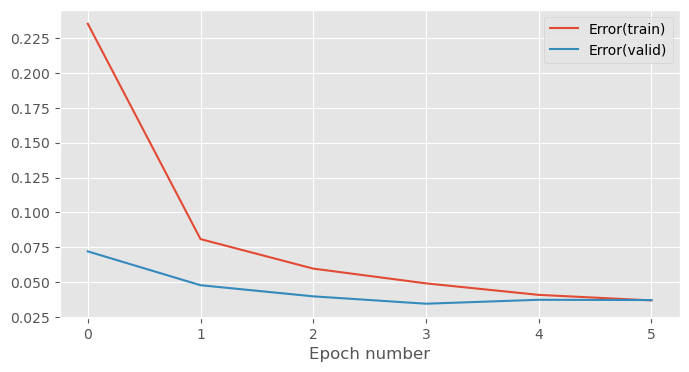

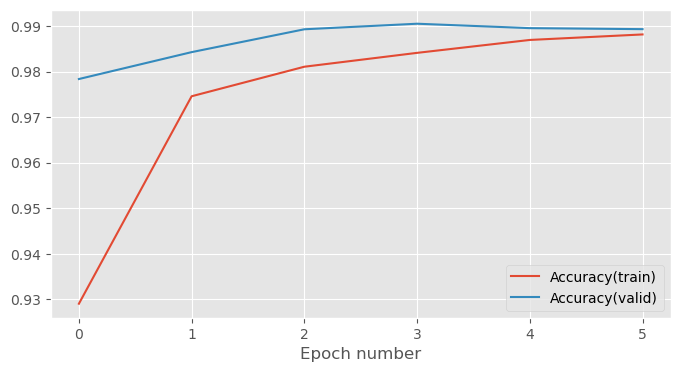

In [17]:
# Plot the change in the validation and training set error over training
fig_1 = plt.figure(figsize=(8, 4))
ax_1 = fig_1.add_subplot(111)
ax_1.plot(train_loss, label='Error(train)')
ax_1.plot(valid_loss, label='Error(valid)')
ax_1.legend(loc=0)
ax_1.set_xlabel('Epoch number')

# Plot the change in the validation and training set accuracy over training
fig_2 = plt.figure(figsize=(8, 4))
ax_2 = fig_2.add_subplot(111)
ax_2.plot(train_acc, label='Accuracy(train)')
ax_2.plot(valid_acc, label='Accuracy(valid)')
ax_2.legend(loc=0)
ax_2.set_xlabel('Epoch number')
plt.show()

## Performance Comparison

Convolutional Neural Networks achieve better performance than Multi-Layer Perceptrons on image datasets. This is because CNNs are able to capture the **spatial structure** of the data through their convolutional and pooling operations. 

**Task:** Compare the results obtained in this lab with those from Lab 3, which introduced multi-layer models. What differences do you observe in terms of accuracy and training speed?

In [18]:
# Testing
test_acc = []
model.eval()
for batch_idx, (x, t) in enumerate(test_loader):
    x = x.to(device)
    t = t.to(device)

    # Forward pass
    y = model(x)
    
    # Calculate accuracy
    _, argmax = torch.max(y, 1)
    acc = (t == argmax.squeeze()).float().mean()
    
    test_acc.append(acc.item())
test_acc = np.mean(test_acc)
print('Accuracy(test): {:.6f}'.format(test_acc))

Accuracy(test): 0.990407
